# ini

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')  # allow importing from parent directory
from fun_gilles import *
import pickle
import pandas as pd

In [29]:
np.linspace(0, 500, 26)

array([  0.,  20.,  40.,  60.,  80., 100., 120., 140., 160., 180., 200.,
       220., 240., 260., 280., 300., 320., 340., 360., 380., 400., 420.,
       440., 460., 480., 500.])

In [30]:
colors = plt.get_cmap('Set2').colors
plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["axes.formatter.useoffset"]=False
import matplotlib.pyplot as plt

# Fine-tune specific elements
plt.rcParams['font.size'] = 12          # Global default
plt.rcParams['axes.titlesize'] = 15     # Individual subplot titles
plt.rcParams['axes.labelsize'] = 15     # x and y labels
plt.rcParams['xtick.labelsize'] = 14    # x-axis tick numbers
plt.rcParams['ytick.labelsize'] = 14    # y-axis tick numbers
plt.rcParams['legend.fontsize'] = 12    # Legend text
plt.rcParams['figure.titlesize'] = 16   # Figure suptitle
plt.rcParams['lines.linewidth'] = 2  # Thicker lines for better visibility
plt.rcParams['axes.linewidth'] = 0.8  # Thicker axes lines

In [31]:
def plot(abundances, times, V, species,fig_name=None, xlim = None):
    """
    Plot de la variación en la concentración y en el volumen
    """

    fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True) 

    # --- Subplot 1 (Left): Concentration ---
    ax1 = axes[0]
    for i in range(len(species)):
        # Calculate Concentration = Abundance / Volume
        ax1.plot(times, abundances[:, i], label=species[i], color=colors[i], alpha=0.9)

    ax1.set_xlabel("Time")
    ax1.set_ylabel("Concentration")
    ax1.set_title("Concentration Evolution")
    ax1.legend(loc='center left', bbox_to_anchor=(1.05, 0.4), title="Species")

    # --- Subplot 2 (Middle): Volume ---
    ax2 = axes[1]
    ax2.plot(times, V, color='gray')
    ax2.set_xlabel("Time")
    ax2.set_ylabel("Volume")
    # ax2.set_yscale("log")
    ax2.set_title("Volume Evolution")
    
    if xlim != None:
        ax1.set_xlim((0,xlim))
        ax2.set_xlim((0,xlim))
   
    # Adjust layout to prevent labels/titles from overlapping
    plt.tight_layout(rect=[0, 0, 1, 1])
    if fig_name != None:
        plt.savefig(f"{fig_name}.png")
    plt.show()

In [ ]:
def plot_conc(abundances, times, V, species, fig_name=None, xlim = None):
    """
    Plot de la variación en la concentración
    """

    fig, axes = plt.subplots(figsize= (7,3)) 
    ax1 = axes
    # --- Subplot 1 (Left): Concentration ---
    for i in range(len(species)):
        # Calculate Concentration = Abundance / Volume
        ax1.plot(times, abundances[:, i] / V, label=species[i], color=colors[i], alpha=0.9)
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Concentration")
    ax1.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), title="Species")
    # Adjust layout to prevent labels/titles from overlapping
    plt.tight_layout(rect=[0, 0, 1, 1])
    if xlim != None:
        ax1.set_xlim((0,xlim))    
    if fig_name != None:
        plt.savefig(f"{fig_name}.png")

    plt.show()
    

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def plot_conc_deterministic_and_stochastic(deterministic:list, stochastic:list, species:list, fig_name=None, xlim = None):
    """
    Plot de la variación en la concentración
    """
    colors = plt.get_cmap('Set2').colors

    con_det, t_det= deterministic
    a_sto, t_sto, v_sto = stochastic
    fig, axes = plt.subplots(figsize=(6,3)) 
    ax1 = axes
    # --- Subplot 1 (Left): Concentration ---
    for i in range(len(species)):
        # Calculate Concentration = Abundance / Volume
        ax1.plot(t_det, con_det[i], label=f"{species[i]} (Deterministic)", color=colors[i], alpha=0.9, linestyle='--')
        ax1.plot(t_sto, a_sto[:, i] / v_sto, label=f"{species[i]} (Stochastic)", color=colors[i], alpha=0.5)
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Concentration")


    line_det = Line2D([0], [0], color='grey', linestyle='--', label='Deterministic')
    line_stoch = Line2D([0], [0], color='grey', linestyle='-', label='Stochastic')
    # Create legend handles for the species (colored patches)
    species_handles = [Patch(color=c, label=name) for c, name in zip(colors, species)]

    handles = species_handles + [line_det, line_stoch]

    ax1.legend(handles=handles, loc="center right")


    spacer = Patch(color='none', label='')
    handles = species_handles + [spacer] + [line_det, line_stoch]

    # Ensure the legend doesn't overlap the plot content    
    plt.tight_layout(rect=[0, 0, 1, 1])
  
    if xlim != None:
        ax1.set_xlim((0,xlim))
    if fig_name != None:
        plt.savefig(f"{fig_name}.png")

    plt.show()

def plot_conc_and_vol_deterministic_and_stochastic(deterministic:list, stochastic:list, species:list, fig_name=None, xlim = None):
    """
    Plot de la variación en la concentración
    """
    colors = plt.get_cmap('Set2').colors

    con_det, t_det, v_det= deterministic
    a_sto, t_sto, v_sto = stochastic
    fig, axes = plt.subplots(figsize=(6,6), nrows=2, ncols=1) 
    ax1 = axes[0]
    # --- Subplot 1 (Left): Concentration ---
    for i in range(len(species)):
        # Calculate Concentration = Abundance / Volume
        ax1.plot(t_det, con_det[i], label=f"{species[i]} (Deterministic)", color=colors[i], alpha=0.9, linestyle='--')
        ax1.plot(t_sto, a_sto[:, i] / v_sto, label=f"{species[i]} (Stochastic)", color=colors[i], alpha=0.5)
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Concentration")

    ax2 = axes[1]
    ax2.plot(t_sto, v_sto, color='black', label='Volume', alpha= 0.5)
    ax2.plot(t_det, v_det, color='black', alpha= 0.9, linestyle='--')
    ax2.set_xlabel("Time")
    ax2.set_ylabel("Volume")
    line_det = Line2D([0], [0], color='grey', linestyle='--', label='Deterministic')
    line_stoch = Line2D([0], [0], color='grey', linestyle='-', label='Stochastic')
    # Create legend handles for the species (colored patches)
    species_handles = [Patch(color=c, label=name) for c, name in zip(colors, species)]

    handles = species_handles + [line_det, line_stoch]

    ax1.legend(handles=handles, loc='center right')
    ax1.set_title("(A)", loc="left",x = -0.05, y=1, pad=10, fontsize=16)
    ax2.set_title("(B)", loc="left",x = -0.05, y=1, pad=10, fontsize=16)



    spacer = Patch(color='none', label='')
    handles = species_handles + [spacer] + [line_det, line_stoch]

    # Ensure the legend doesn't overlap the plot content    
    plt.tight_layout(rect=[0, 0, 1, 1])
  
    if xlim != None:
        ax1.set_xlim((0,xlim))
    if fig_name != None:
        plt.savefig(f"{fig_name}.png")

    plt.show()

# Figure 1

In [51]:
xyc_file = "../examples/reactions_XYC.txt"
xyc_species= ["c","x", "y", "xc", "xy"]
a_xyc, t_xyc, v_xyc = chemistry(method= "Gillespie",
                                iterations= 5e4,
                                file= xyc_file,
                                initial_food= [100, 1000, 1000, 0, 0],
                                k= [1]* 4,
                                V= 1000)
a_det, t_det, v_det = chemistry(method= "Deterministic",
                                iterations= 300,
                                file= xyc_file,
                                initial_food= [100, 1000, 1000, 0, 0],
                                k= [1]* 4,
                                V= 1000)

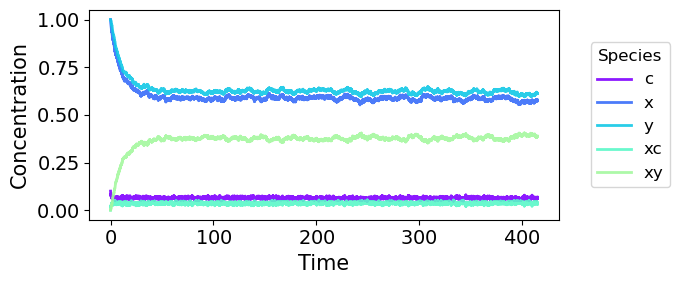

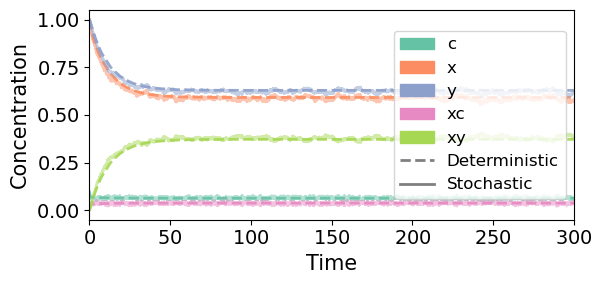

In [52]:
plot_conc(a_xyc, t_xyc, v_xyc, xyc_species, fig_name= "XYC_time_evolution")
plot_conc_deterministic_and_stochastic((a_det.T/v_det, t_det), (a_xyc, t_xyc, v_xyc), 
                                       xyc_species, fig_name= "XYC_time_evolution_comparison", xlim= 300)

Criterion for stop was # of iterations
17.62670169910722


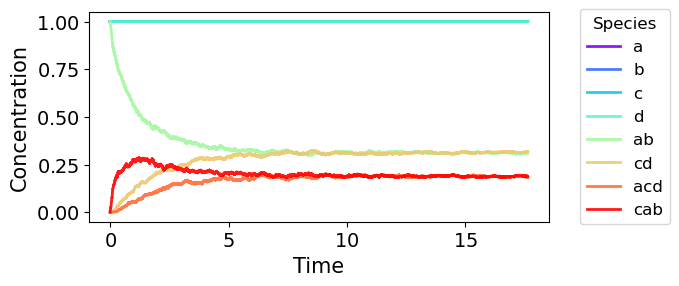

In [53]:
f= "../examples/reactions_autocat.txt"
species= obtain_species(read_file(f))
a, t, v= chemistry(method= "Protocell",
                   file=f,
                   iterations= 2e5,
                   initial_food=[1000]*4 + [1000]*1 + [0]*3,
                   k = [1]*8,
                   V= 1000,
                   threshold=0)
print(t[-1])
plot_conc(a, t, v, species, fig_name= "autocat_time_evolution")

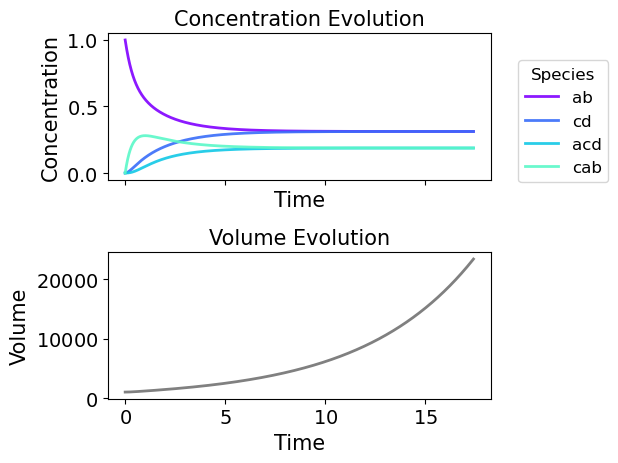

In [54]:
K_intermediates = [1]*8
def odes_intermediates(t, X, K_intermediates):
    V, ab, cd, acd, cab = X
    a, b, c, d = 1, 1, 1, 1
    k1, k2, k3, k4, k5, k6, k7, k8 = K_intermediates
    fi = 1
    dVdt = (V/fi) * (k3 * b * acd + k7 * d * cab - k4 * ab * cd - k8 * ab * cd)
    dabdt = k3 * b * acd + k6 * cab + k7 * cab * d - k4 * ab * cd - k5 * ab * c - k8 * cd * ab - (ab / V) * dVdt
    dcddt = k3 * b * acd + k7 * cab * d + k2 * acd - k4 * ab * cd - k1 * a * cd - k8 * cd * ab - (cd / V) * dVdt
    dacddt = k4 * ab * cd + k1 * a * cd - k3 * b * acd - k2 * acd - (acd / V) * dVdt
    dcabdt = k5 * ab * c + k8 * cd * ab - k6 * cab - k7 * cab * d - (cab / V) * dVdt
    return [dVdt, dabdt, dcddt, dacddt, dcabdt]
    
t_end= 17.4
t_span = (0, t_end)
y0 = [1000, 1, 0, 0, 0]
sol = solve_ivp(odes_intermediates, t_span, y0, t_eval=np.linspace(0, t_end, 5000), method='BDF', args=(K_intermediates,))
plot(sol.y[1:].T, sol.t, sol.y[0], species[4:], fig_name= "Autocatalytic_time_evolution_deterministic")

In [55]:
print(f"Abundance shape: {a.shape}")
print(f"Time shape: {t.shape}")
print(f"Volume shape: {v.shape}")

Abundance shape: (200001, 8)
Time shape: (200001,)
Volume shape: (200001,)


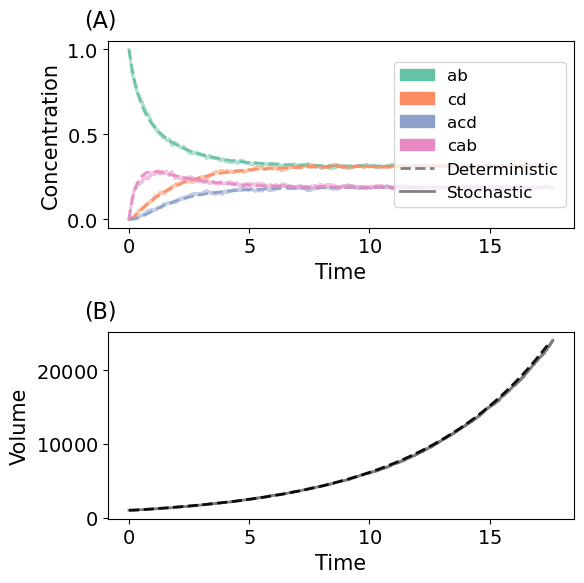

In [58]:
plot_conc_and_vol_deterministic_and_stochastic((sol.y[1:], sol.t, sol.y[0]),(a[:,4:], t, v), species[4:], fig_name= "Autocatalytic_time_evolution_comparison")